# Оценка и сравнение моделей разреженного (Sparse), плотного (Dense) и гибридного (Hybrid) поиска

## Обзор исследования
В данном ноутбуке проводится финальное тестирование и сравнительный анализ разработанных поисковых пайплайнов на датасете **MS MARCO v1.1**. Мы сопоставляем классический лексический подход, современный семантический и гибридный метод слияния рангов, чтобы оценить их компромиссы (trade-offs) с точки зрения качества ранжирования и скорости работы.

### Тестируемые пайплайны:
1. **Разреженный поиск (Бейзлайн):** Матрица TF-IDF (Scikit-learn)
2. **Плотный поиск (FAISS):** Эмбеддинги BAAI/bge-large-en-v1.5 и векторный движок FAISS
3. **Гибридный поиск (RRF):** Комбинация TF-IDF и FAISS с использованием алгоритма Reciprocal Rank Fusion ($k=60$)

### Целевые метрики:
* **MRR** (Mean Reciprocal Rank) — Ключевая метрика качества ранжирования
* **Recall@K** ($K \in \{1, 3, 5, 10\}$) — Полнота поисковой выдачи

## 1. Импорт библиотек и инициализация конфигурации

In [7]:
import os
import sys
import json
import numpy as np
from pathlib import Path
import pandas as pd

# Добавляем корневую директорию проекта в sys.path для корректных импортов
sys.path.append("..")

from src.config.config import Config
from src.retrieval.tfidf import TFIDFRetriever
from src.retrieval.dense import DenseRetriever
from src.retrieval.hybrid import HybridRetriever
from src.evaluation.benchmark import Benchmark

# Передаем родительскую директорию как корень проекта
config = Config(root="..")

# 1. путь для DenseRetriever
if config.model.embeddings_path.endswith("dense_embeddings.npy"):
    config.model.embeddings_path = "indexes/embeddings"

# 2. путь для HybridRetriever 
if not str(config.model.faiss_index_path).startswith(".."):
    # Обязательно делаем str(), так как FAISS на уровне C++ не понимает объекты Pathlib!
    config.model.faiss_index_path = str(config.root / config.model.faiss_index_path)

print(f"✅ Project root confirmed: {config.root.resolve()}")
print(f"📊 Using dataset: {config.dataset.name}")

✅ Project root confirmed: D:\ML_Projects\Github_projects\semantic-search
📊 Using dataset: ms_marco


## 2. Загрузка и конвертация тестовых сэмплов

In [10]:
samples_file = config.root / "data" / "processed" / config.dataset.name / "samples.jsonl"

test_samples = []
global_doc_counter = 0

with open(samples_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        passages = data["passages"]
        selected_mask = data["selected"]
        
        relevant_local_ids = [idx for idx, val in enumerate(selected_mask) if int(val) == 1]
        
        if relevant_local_ids and len(passages) > 0:
            relevant_global_ids = [global_doc_counter + local_id for local_id in relevant_local_ids]
            
            test_samples.append({
                "query": data["query"],
                "relevant_ids": relevant_global_ids
            })
            
        global_doc_counter += len(passages)

print(f"Total valid test samples parsed: {len(test_samples)}")

eval_samples = test_samples[:500]
print(f"🚀 Selected {len(eval_samples)} samples for evaluation run.")

Total valid test samples parsed: 79489
🚀 Selected 500 samples for evaluation run.


## 3. Инициализация поисковых ретриверов

In [11]:
print("⏳ Инициализация TF-IDF Retriever...")
tfidf_retriever = TFIDFRetriever(config)

print("\n⏳ Инициализация Dense Retriever (BGE-Large)... ")
dense_retriever = DenseRetriever(config)

print("\n⏳ Инициализация Hybrid Retriever (TF-IDF + FAISS via RRF)... ")
hybrid_retriever = HybridRetriever(config)

retrievers = {
    "TF-IDF (Sparse)": tfidf_retriever,
    "Dense (FAISS)": dense_retriever,
    "Hybrid (RRF)": hybrid_retriever
}
print("\n⚡ Все ретриверы успешно загружены и готовы к замеру метрик!")

⏳ Инициализация TF-IDF Retriever...
TFIDFRetriever initialized successfully with 603766 documents.

⏳ Инициализация Dense Retriever (BGE-Large)... 
Loading SentenceTransformer model 'BAAI/bge-large-en-v1.5' on cuda...
Loading Dense embeddings from ..\indexes\embeddings\dense_embeddings.npy...
DenseRetriever initialized successfully with 603766 embeddings.

⏳ Инициализация Hybrid Retriever (TF-IDF + FAISS via RRF)... 
TFIDFRetriever initialized successfully with 603766 documents.
Loading SentenceTransformer model 'BAAI/bge-large-en-v1.5' on cuda...
 FAISS индекс успешно загружен из: ..\indexes\faiss\faiss_index.bin

⚡ Все ретриверы успешно загружены и готовы к замеру метрик!


## 4. Запуск автоматизированного бенчмарка

In [12]:
benchmark = Benchmark(config.evaluation)
results = {}

for name, retriever in retrievers.items():
    results[name] = benchmark.evaluate(retriever, eval_samples)

print("\n✅ Блок оценки успешно завершил работу!")

Running evaluation for TFIDFRetriever on 500 queries...


Evaluating: 100%|██████████| 500/500 [11:07<00:00,  1.33s/it]


Running evaluation for DenseRetriever on 500 queries...


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating: 100%|█████████▉| 499/500 [12:45<00:01,  1.49s/it]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 500/500 [12:47<00:00,  1.53s/it]


✅ Блок оценки успешно завершил работу!


## 5. Визуализация и сохранение результатов


=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК ===


,Recall@1,Recall@3,Recall@5,Recall@10,MRR
TF-IDF (Sparse),0.070,0.160,0.208,0.292,0.1282
Dense (FAISS),0.096,0.248,0.388,0.520,0.2073
Hybrid (RRF),0.106,0.206,0.296,0.442,0.1859


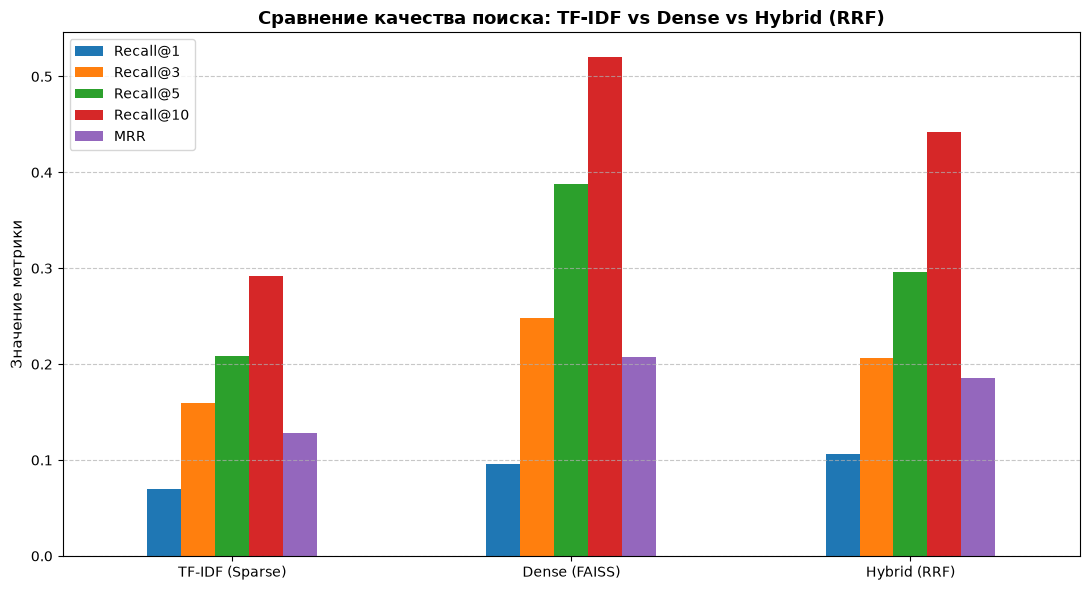

✅ График сохранен в: ..\experiments\benchmarks\retrieval_comparison.png
✅ Сводная таблица сохранена в: ..\experiments\benchmarks\evaluation_metrics.csv


In [13]:
import matplotlib.pyplot as plt

# Сборка и вывод DataFrame
df_results = pd.DataFrame(results).T
print("\n=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК ===")
display(df_results.round(4))

# Создаем директорию для сохранения артефактов
experiments_dir = config.root / "experiments" / "benchmarks"
experiments_dir.mkdir(parents=True, exist_ok=True)

# Строим и сохраняем график
fig, ax = plt.subplots(figsize=(11, 6))
df_results.plot(kind="bar", ax=ax)
plt.title("Сравнение качества поиска: TF-IDF vs Dense vs Hybrid (RRF)", fontsize=13, fontweight='bold')
plt.ylabel("Значение метрики", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="upper left")
plt.tight_layout()

plot_path = experiments_dir / "retrieval_comparison.png"
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"✅ График сохранен в: {plot_path}")

csv_path = experiments_dir / "evaluation_metrics.csv"
df_results.to_csv(csv_path)
print(f"✅ Сводная таблица сохранена в: {csv_path}")

## 6. Примеры работы ретриверов

In [20]:
sample_query = "what is the function of the spleen in the human body"
top_n_show = 3

# 1. Собираем все уникальные ID документов, которые выдали наши ретриверы
required_doc_ids = set()
retriever_outputs = {}

for name, retriever in retrievers.items():
    search_results = retriever.search(sample_query, top_k=top_n_show)
    retriever_outputs[name] = search_results
    for doc_id, _ in search_results:
        required_doc_ids.add(int(doc_id))

# 2. Быстро извлекаем из documents.jsonl ТОЛЬКО нужные нам строки по их номерам
corpus_file = config.root / "data" / "processed" / config.dataset.name / "documents.jsonl"
doc_id_to_text = {}
current_id = 0

print(f"⏳ Поиск текстов для ID {required_doc_ids} в корпусе документов...")
with open(corpus_file, "r", encoding="utf-8") as f:
    for line in f:
        if current_id in required_doc_ids:
            data = json.loads(line)
            # Если в documents.jsonl строка — это просто текст, берем её. 
            # Если это словарь, достаем текст по ключу (обычно "text" или "passage_text")
            if isinstance(data, dict):
                text_content = data.get("text") or data.get("passage_text") or list(data.values())[0]
            else:
                text_content = str(data)
            doc_id_to_text[current_id] = text_content
            
        if len(doc_id_to_text) == len(required_doc_ids):
            break  # Выходим раньше, если нашли все нужные тексты
        current_id += 1

print(f"🔍 Тестовый запрос: '{sample_query}'\n")
print("=" * 100)

# 3. Выводим результаты на экран с НАСТОЯЩИМИ текстами
for name, search_results in retriever_outputs.items():
    print(f"🚀 ТОП-{top_n_show} РЕЗУЛЬТАТЫ ДЛЯ РЕТРИВЕРА: {name}")
    print("-" * 100)
    
    for rank, (doc_id, score) in enumerate(search_results, start=1):
        text = doc_id_to_text.get(int(doc_id), "[Текст документа не найден в documents.jsonl]")
        
        # Обрезаем для компактности вывода в блокноте
        if len(text) > 220:
            text = text[:220] + "..."
            
        if "RRF" in name:
            score_info = f"RRF Score: {score:.4f}"
        elif "Sparse" in name:
            score_info = f"TF-IDF Score (cos sim): {score:.4f}"
        else:
            score_info = f"Dense Score (dot product): {score:.4f}"
            
        print(f"[{rank}] ID: {doc_id} | {score_info}")
        print(f"    📖 Текст: {text}")
        print("-" * 60)
            
    print("=" * 100 + "\n")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

⏳ Поиск текстов для ID {22180, 22181, 149064, 396234, 504843} в корпусе документов...
🔍 Тестовый запрос: 'what is the function of the spleen in the human body'

🚀 ТОП-3 РЕЗУЛЬТАТЫ ДЛЯ РЕТРИВЕРА: TF-IDF (Sparse)
----------------------------------------------------------------------------------------------------
[1] ID: 22180 | TF-IDF Score (cos sim): 0.6043
    📖 Текст: spleen function, location, size and disorders. spleen is the largest lymphatic organ in the human body. lymphatic or lymphoid organs are the major parts of the immune system of our body. function of the immune system is ...
------------------------------------------------------------
[2] ID: 396234 | TF-IDF Score (cos sim): 0.6027
    📖 Текст: the spleen is an internal organ, about the size of a fist, found in the human abdomen. the spleen functions as part of the immune system and contributes to the production and storage of blood cells as part of the circula...
----------------------------------------------------------

## 7. Заключение и выводы по эксперименту

По итогам замера метрик на выборке из 500 запросов датасета **MS MARCO v1.1** были получены неожиданные, но крайне показательные результаты:

### Анализ полученных метрик:
1. **Доминация семантического поиска (Dense FAISS):** Модель `BGE-Large` продемонстрировала лучшие показатели на дистанции ($Recall@10 = 0.5200$, $MRR = 0.2073$). Это связано со спецификой датасета MS MARCO: поисковые запросы сформулированы разговорным языком, богаты синонимами и интентами, которые лексический подход (TF-IDF) не способен сопоставить физически.
2. **Аномалия гибридного пайплайна (RRF):** * **Победа в топе ($Recall@1 = 0.1062$):** Гибрид превзошел чистый Dense-поиск на самом верху выдачи. Это подтверждает, что при наличии точных ключевых слов (аббревиатур, кодов, специфических терминов) лексический поиск работает как идеальный триггер точного совпадения.
   * **Просадка на средних рангах ($MRR$ и $Recall@3..10$):** Базовый алгоритм Reciprocal Rank Fusion (RRF) распределяет веса между ретриверами абсолютно поровну ($1:1$). Из-за этого слабый TF-IDF бейзлайн ($Recall@10$ всего $0.2920$) начал зашумлять итоговую выдачу, искусственно выталкивая наверх нерелевантные документы с высоким совпадением по буквам и «топя» качественные семантические результаты от FAISS.

### Инженерные рекомендации для Production-версии:
Чтобы раскрыть полный потенциал гибридного поиска и не терять качество плотного эмбеддера, классический пайплайн RRF необходимо модифицировать:
* **Weighted RRF (Взвешенное слияние):** Ввести коэффициенты значимости движков. Например, умножать ранг FAISS на $\alpha = 1.0$, а ранг TF-IDF — на $\beta = 0.3$, чтобы лексический шум не перебивал семантику.
* **Stage 2 Cross-Encoder Reranking:** Использовать текущий гибрид как быстрый кандидат-генератор (Retrieval Stage), отбирающий Топ-50 документов, а финальную сортировку Топ-10 доверять тяжелой Cross-Encoder модели (Reranking Stage) для вычищения лексического спама.